# 📈 Body Performance Dataset — Model Evaluation & Comparison
**File 5 of 5 | Diploma Project**

---

## 🎯 Objective
Evaluate all **6 trained models** across **3 train/test split trials** on their respective
held-out test sets. Compare performance using multiple metrics and generate
publication-quality visualisations.

| Trial | Split  | Train rows | Test rows |
|-------|--------|-----------|----------|
| T1    | 80:20  | 10,630    | 2,658    |
| T2    | 70:30  | 9,301     | 3,987    |
| T3    | 50:50  | 6,644     | 6,644    |

## 📐 Evaluation Metrics
| Metric | What it measures |
|--------|-----------------|
| **Accuracy** | Overall % of correct predictions |
| **Macro Precision** | Average precision across classes (equal class weight) |
| **Macro Recall** | Average recall across classes (equal class weight) |
| **Macro F1** | Harmonic mean of Precision & Recall |
| **Weighted F1** | F1 weighted by class support — handles any imbalance |
| **Confusion Matrix** | Per-class prediction breakdown |

## 🔒 No Data Leakage Guarantee
Test sets were created with a fixed random seed (`random_state=42`) and stratified
splits in `04_Modelling.ipynb`. They have not been touched since.
Models are loaded from `.pkl` files produced by that notebook.
The CSV files (`X_test_t*.csv`, `y_test_t*.csv`) are the matching held-out test sets.

## 🔧 Section 1 — Imports & Global Configuration

In [1]:
import pandas as pd
import numpy  as np
import pickle
import os
import warnings
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
    precision_score, recall_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Global constants ────────────────────────────────────────────────────
CLASS_NAMES  = ["D (Worst)", "C", "B", "A (Best)"]
CLASS_LABELS = [0, 1, 2, 3]

MODEL_NAMES  = ["KNN", "LogisticReg", "DecisionTree",
                "SVM", "NeuralNetwork", "RandomForest"]

TRIALS = [
    {"tag": "t1", "label": "Trial 1 (80:20)", "split": "80:20"},
    {"tag": "t2", "label": "Trial 2 (70:30)", "split": "70:30"},
    {"tag": "t3", "label": "Trial 3 (50:50)", "split": "50:50"},
]

# Colour palettes
PALETTE_6     = ["#3498db","#2ecc71","#e67e22","#e74c3c","#9b59b6","#1abc9c"]
PALETTE_TRIAL = ["#2ecc71", "#f39c12", "#e74c3c"]   # T1 green, T2 orange, T3 red

MODEL_COLOR = dict(zip(MODEL_NAMES, PALETTE_6))

print("✅ Libraries loaded")
print(f"   Models  : {MODEL_NAMES}")
print(f"   Trials  : {[t['label'] for t in TRIALS]}")
print(f"   Classes : {CLASS_NAMES}")

✅ Libraries loaded
   Models  : ['KNN', 'LogisticReg', 'DecisionTree', 'SVM', 'NeuralNetwork', 'RandomForest']
   Trials  : ['Trial 1 (80:20)', 'Trial 2 (70:30)', 'Trial 3 (50:50)']
   Classes : ['D (Worst)', 'C', 'B', 'A (Best)']


## 📥 Section 2 — Load Test Data & Trained Models

**Data files** (`X_test_t*.csv`, `y_test_t*.csv`, `X_train_t*.csv`, `y_train_t*.csv`)
are the CSV splits saved by `04_Modelling.ipynb`.

**Model files** (`model_t*_*.pkl`) are the serialised `Pipeline` objects
(StandardScaler + tuned classifier) produced by `RandomizedSearchCV`.

> ⚠️  Place all files in the **same directory** as this notebook, or adjust
> the `DATA_DIR` and `MODEL_DIR` paths below.

In [5]:
# ── Path configuration ───────────────────────────────────────────────────
# If running on Google Colab with Drive, set these to your Drive path, e.g.:
#   DATA_DIR  = "/content/drive/MyDrive/project/"
#   MODEL_DIR = "/content/drive/MyDrive/project/"
# If all files are in the same folder as this notebook, leave as ".".

DATA_DIR  = "/content/"   # folder containing X_test_t*.csv, y_test_t*.csv, etc.
MODEL_DIR = "/content/"   # folder containing model_t*_*.pkl

# ── Load data for every trial ────────────────────────────────────────────
trial_data = {}   # trial_data[tag] = {X_train, y_train, X_test, y_test}

for t in TRIALS:
    tag = t["tag"]
    X_test  = pd.read_csv(os.path.join(DATA_DIR, f"X_test_{tag}.csv"))
    y_test  = pd.read_csv(os.path.join(DATA_DIR, f"y_test_{tag}.csv")).squeeze()
    X_train = pd.read_csv(os.path.join(DATA_DIR, f"X_train_{tag}.csv"))
    y_train = pd.read_csv(os.path.join(DATA_DIR, f"y_train_{tag}.csv")).squeeze()

    trial_data[tag] = dict(X_test=X_test, y_test=y_test,
                            X_train=X_train, y_train=y_train)

    print(f"  {t['label']:20s}  "
          f"Train {X_train.shape[0]:>6,} rows  |  "
          f"Test {X_test.shape[0]:>6,} rows  |  "
          f"{X_test.shape[1]} features")

FEATURE_NAMES = trial_data["t1"]["X_test"].columns.tolist()
print(f"\nFeatures ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

# ── Load trained model pipelines ─────────────────────────────────────────
# models[tag][model_name] = fitted Pipeline
models = {t["tag"]: {} for t in TRIALS}

print("\nLoading model .pkl files:")
for t in TRIALS:
    tag = t["tag"]
    for name in MODEL_NAMES:
        path = os.path.join(MODEL_DIR, f"model_{tag}_{name}.pkl")
        if os.path.exists(path):
            with open(path, "rb") as f:
                models[tag][name] = pickle.load(f)
            print(f"  ✅ {path}")
        else:
            print(f"  ⚠  NOT FOUND: {path}")
            models[tag][name] = None

print("\n✅ Data and models ready.")

  Trial 1 (80:20)       Train 10,630 rows  |  Test  2,658 rows  |  12 features
  Trial 2 (70:30)       Train  9,301 rows  |  Test  3,987 rows  |  12 features
  Trial 3 (50:50)       Train  6,644 rows  |  Test  6,644 rows  |  12 features

Features (12): ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'BMI']

Loading model .pkl files:
  ✅ /content/model_t1_KNN.pkl
  ✅ /content/model_t1_LogisticReg.pkl
  ✅ /content/model_t1_DecisionTree.pkl
  ✅ /content/model_t1_SVM.pkl
  ✅ /content/model_t1_NeuralNetwork.pkl
  ✅ /content/model_t1_RandomForest.pkl
  ✅ /content/model_t2_KNN.pkl
  ✅ /content/model_t2_LogisticReg.pkl
  ✅ /content/model_t2_DecisionTree.pkl
  ✅ /content/model_t2_SVM.pkl
  ✅ /content/model_t2_NeuralNetwork.pkl
  ✅ /content/model_t2_RandomForest.pkl
  ✅ /content/model_t3_KNN.pkl
  ✅ /content/model_t3_LogisticReg.pkl
  ✅ /content/model_t3_DecisionTree.pkl
  ✅ /content/mod

## 🧮 Section 3 — Generate Predictions & Compute All Metrics

For every trial × model combination we compute:
- Test Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1
- Full per-class confusion matrix
- Full `classification_report` string

In [6]:
all_results   = []          # flat list of dicts → DataFrame later
conf_matrices = {}          # conf_matrices[(tag, name)] = ndarray
reports_dict  = {}          # reports_dict [(tag, name)] = report string
predictions   = {}          # predictions  [(tag, name)] = y_pred array

for t in TRIALS:
    tag   = t["tag"]
    X_tst = trial_data[tag]["X_test"]
    y_tst = trial_data[tag]["y_test"]

    print(f"\n{'─'*55}")
    print(f"  {t['label']}")
    print(f"{'─'*55}")
    print(f"  {'Model':<16} {'Acc':>7} {'MacPrec':>9} {'MacRec':>8} {'MacF1':>8} {'WtF1':>8}")
    print(f"  {'─'*60}")

    for name in MODEL_NAMES:
        model = models[tag].get(name)
        if model is None:
            print(f"  {name:<16}  ⚠  Model not loaded — skipping.")
            continue

        y_pred = model.predict(X_tst)
        predictions[(tag, name)] = y_pred

        acc   = accuracy_score(y_tst, y_pred)
        mp    = precision_score(y_tst, y_pred, average="macro",    zero_division=0)
        mr    = recall_score(y_tst,   y_pred, average="macro",    zero_division=0)
        mf1   = f1_score(y_tst,       y_pred, average="macro",    zero_division=0)
        wf1   = f1_score(y_tst,       y_pred, average="weighted", zero_division=0)

        all_results.append({
            "Trial"          : t["label"],
            "Split"          : t["split"],
            "Model"          : name,
            "Test Accuracy"  : acc,
            "Macro Precision": mp,
            "Macro Recall"   : mr,
            "Macro F1"       : mf1,
            "Weighted F1"    : wf1,
        })

        conf_matrices[(tag, name)] = confusion_matrix(
            y_tst, y_pred, labels=CLASS_LABELS)
        reports_dict[(tag, name)] = classification_report(
            y_tst, y_pred, target_names=CLASS_NAMES, zero_division=0)

        print(f"  {name:<16} {acc:>7.4f} {mp:>9.4f} {mr:>8.4f} {mf1:>8.4f} {wf1:>8.4f}")

# ── Build results DataFrames ─────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df.to_csv("results_summary_all_trials.csv", index=False)
print("\n✅ results_summary_all_trials.csv saved")

# Per-trial sorted tables
for t in TRIALS:
    sub = (results_df[results_df["Trial"] == t["label"]]
           .sort_values("Test Accuracy", ascending=False)
           .reset_index(drop=True))
    sub.to_csv(f"results_summary_{t['tag']}.csv", index=False)
    print(f"  Saved: results_summary_{t['tag']}.csv")


───────────────────────────────────────────────────────
  Trial 1 (80:20)
───────────────────────────────────────────────────────
  Model                Acc   MacPrec   MacRec    MacF1     WtF1
  ────────────────────────────────────────────────────────────
  KNN               0.6381    0.6579   0.6383   0.6399   0.6393
  LogisticReg       0.6204    0.6174   0.6211   0.6188   0.6181
  DecisionTree      0.6806    0.6863   0.6810   0.6826   0.6820
  SVM               0.7193    0.7218   0.7198   0.7189   0.7184
  NeuralNetwork     0.7592    0.7666   0.7596   0.7592   0.7588
  RandomForest      0.7532    0.7600   0.7535   0.7547   0.7543

───────────────────────────────────────────────────────
  Trial 2 (70:30)
───────────────────────────────────────────────────────
  Model                Acc   MacPrec   MacRec    MacF1     WtF1
  ────────────────────────────────────────────────────────────
  KNN               0.6396    0.6551   0.6397   0.6410   0.6406
  LogisticReg       0.6173    0.6125

### Full Classification Reports — All Trials

In [7]:
for t in TRIALS:
    tag = t["tag"]
    print(f"\n{'='*65}")
    print(f"  {t['label']} — Classification Reports")
    print(f"{'='*65}")
    for name in MODEL_NAMES:
        if (tag, name) not in reports_dict:
            continue
        print(f"\n  ── {name} ──")
        print(reports_dict[(tag, name)])


  Trial 1 (80:20) — Classification Reports

  ── KNN ──
              precision    recall  f1-score   support

   D (Worst)       0.92      0.67      0.78       657
           C       0.60      0.57      0.58       668
           B       0.48      0.49      0.48       667
    A (Best)       0.63      0.83      0.72       666

    accuracy                           0.64      2658
   macro avg       0.66      0.64      0.64      2658
weighted avg       0.66      0.64      0.64      2658


  ── LogisticReg ──
              precision    recall  f1-score   support

   D (Worst)       0.78      0.78      0.78       657
           C       0.54      0.52      0.53       668
           B       0.47      0.45      0.46       667
    A (Best)       0.68      0.74      0.71       666

    accuracy                           0.62      2658
   macro avg       0.62      0.62      0.62      2658
weighted avg       0.62      0.62      0.62      2658


  ── DecisionTree ──
              precision    rec

## 📊 Section 4 — Per-Trial Comparison Bar Charts (All Metrics)

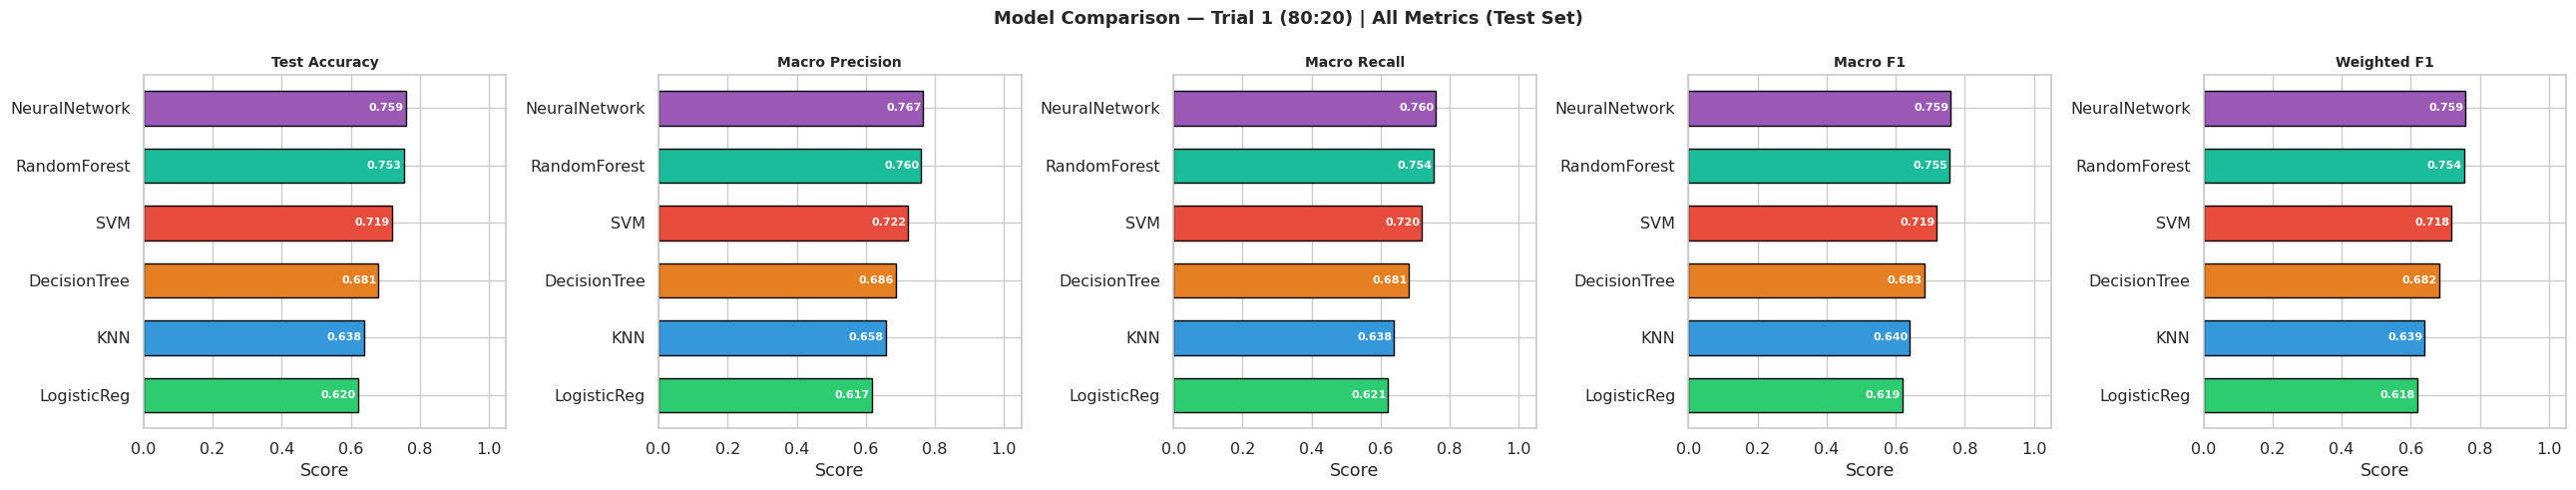

  Saved: bar_metrics_t1.png


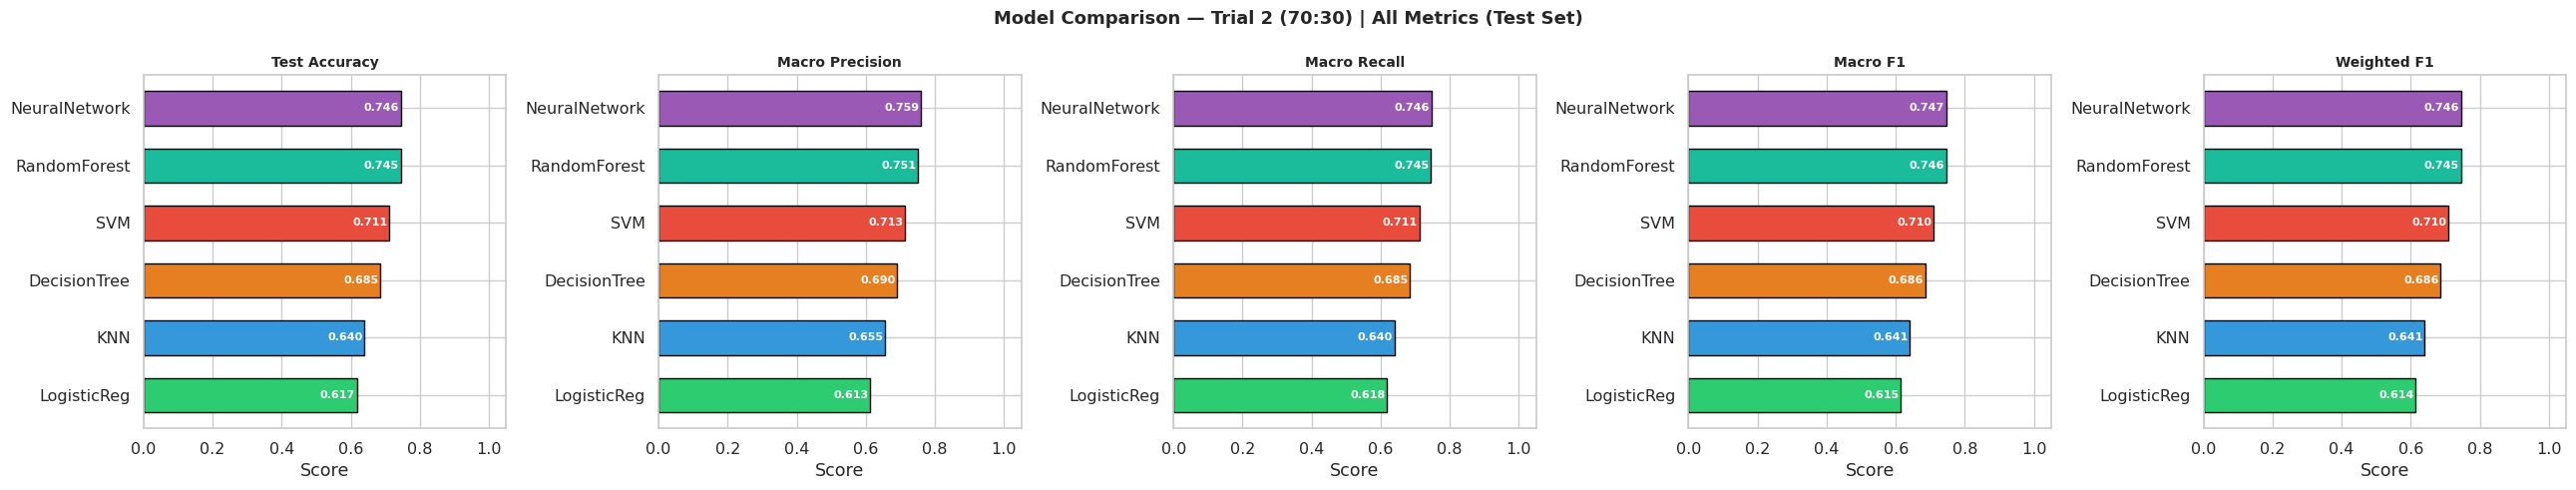

  Saved: bar_metrics_t2.png


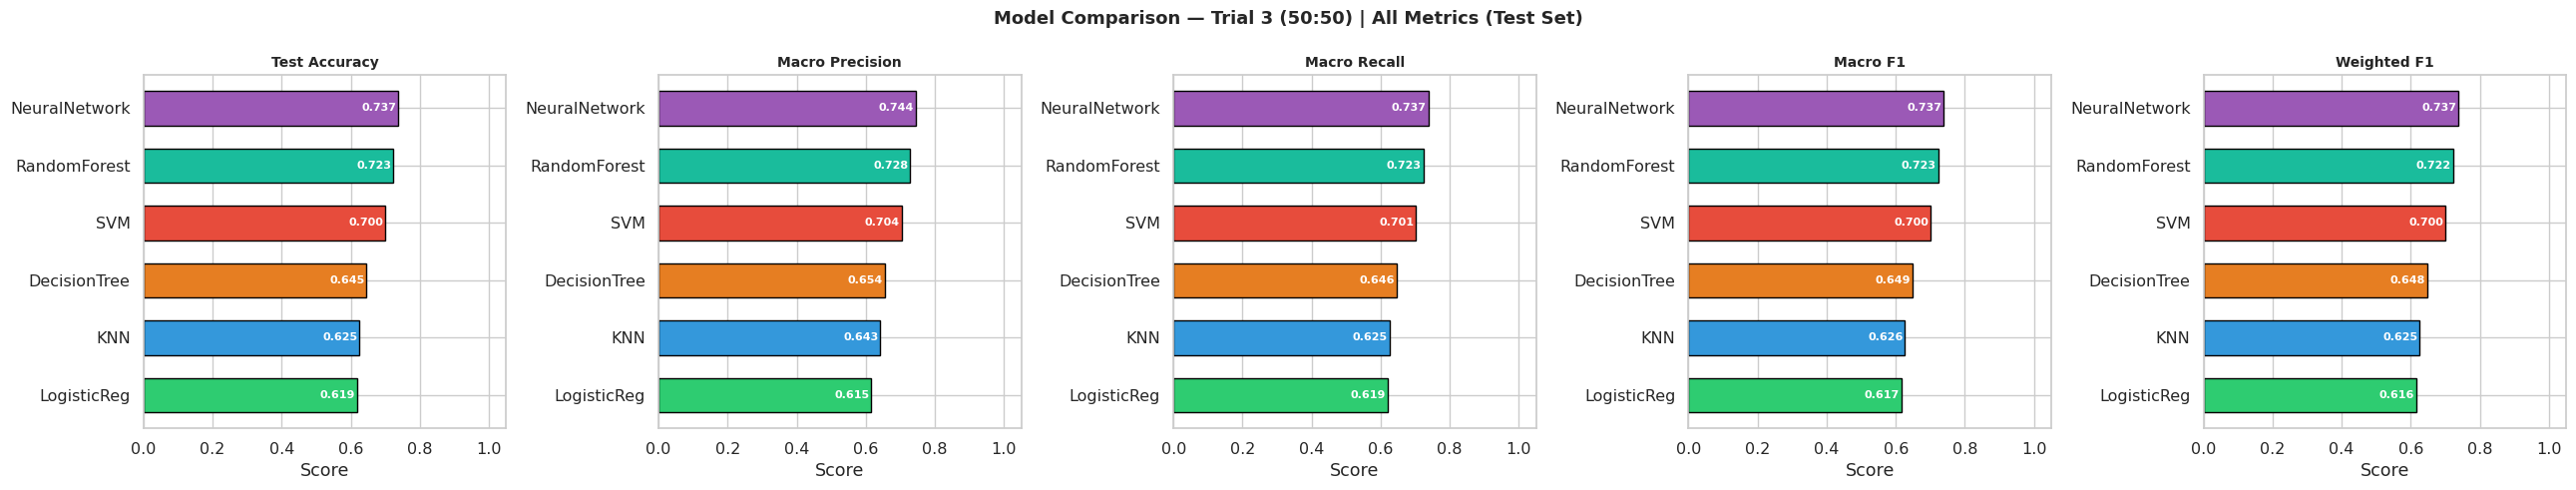

  Saved: bar_metrics_t3.png


In [8]:
metrics_to_plot = ["Test Accuracy", "Macro Precision",
                   "Macro Recall", "Macro F1", "Weighted F1"]

for t in TRIALS:
    sub = (results_df[results_df["Trial"] == t["label"]]
           .sort_values("Test Accuracy", ascending=False)
           .reset_index(drop=True))

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(26, 5))
    fig.suptitle(f"Model Comparison — {t['label']} | All Metrics (Test Set)",
                 fontsize=13, fontweight="bold")

    for ax, metric in zip(axes, metrics_to_plot):
        sdf  = sub.sort_values(metric, ascending=True)
        cols = [MODEL_COLOR[m] for m in sdf["Model"]]
        bars = ax.barh(sdf["Model"], sdf[metric],
                       color=cols, edgecolor="black", height=0.6)
        for bar, val in zip(bars, sdf[metric]):
            ax.text(val - 0.005, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va="center", ha="right",
                    fontsize=8, fontweight="bold", color="white")
        ax.set_xlim(0, 1.05)
        ax.set_title(metric, fontweight="bold", fontsize=10)
        ax.set_xlabel("Score")

    plt.tight_layout()
    plt.savefig(f"bar_metrics_{t['tag']}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: bar_metrics_{t['tag']}.png")

## 🟦 Section 5 — Confusion Matrices (All 6 Models per Trial)

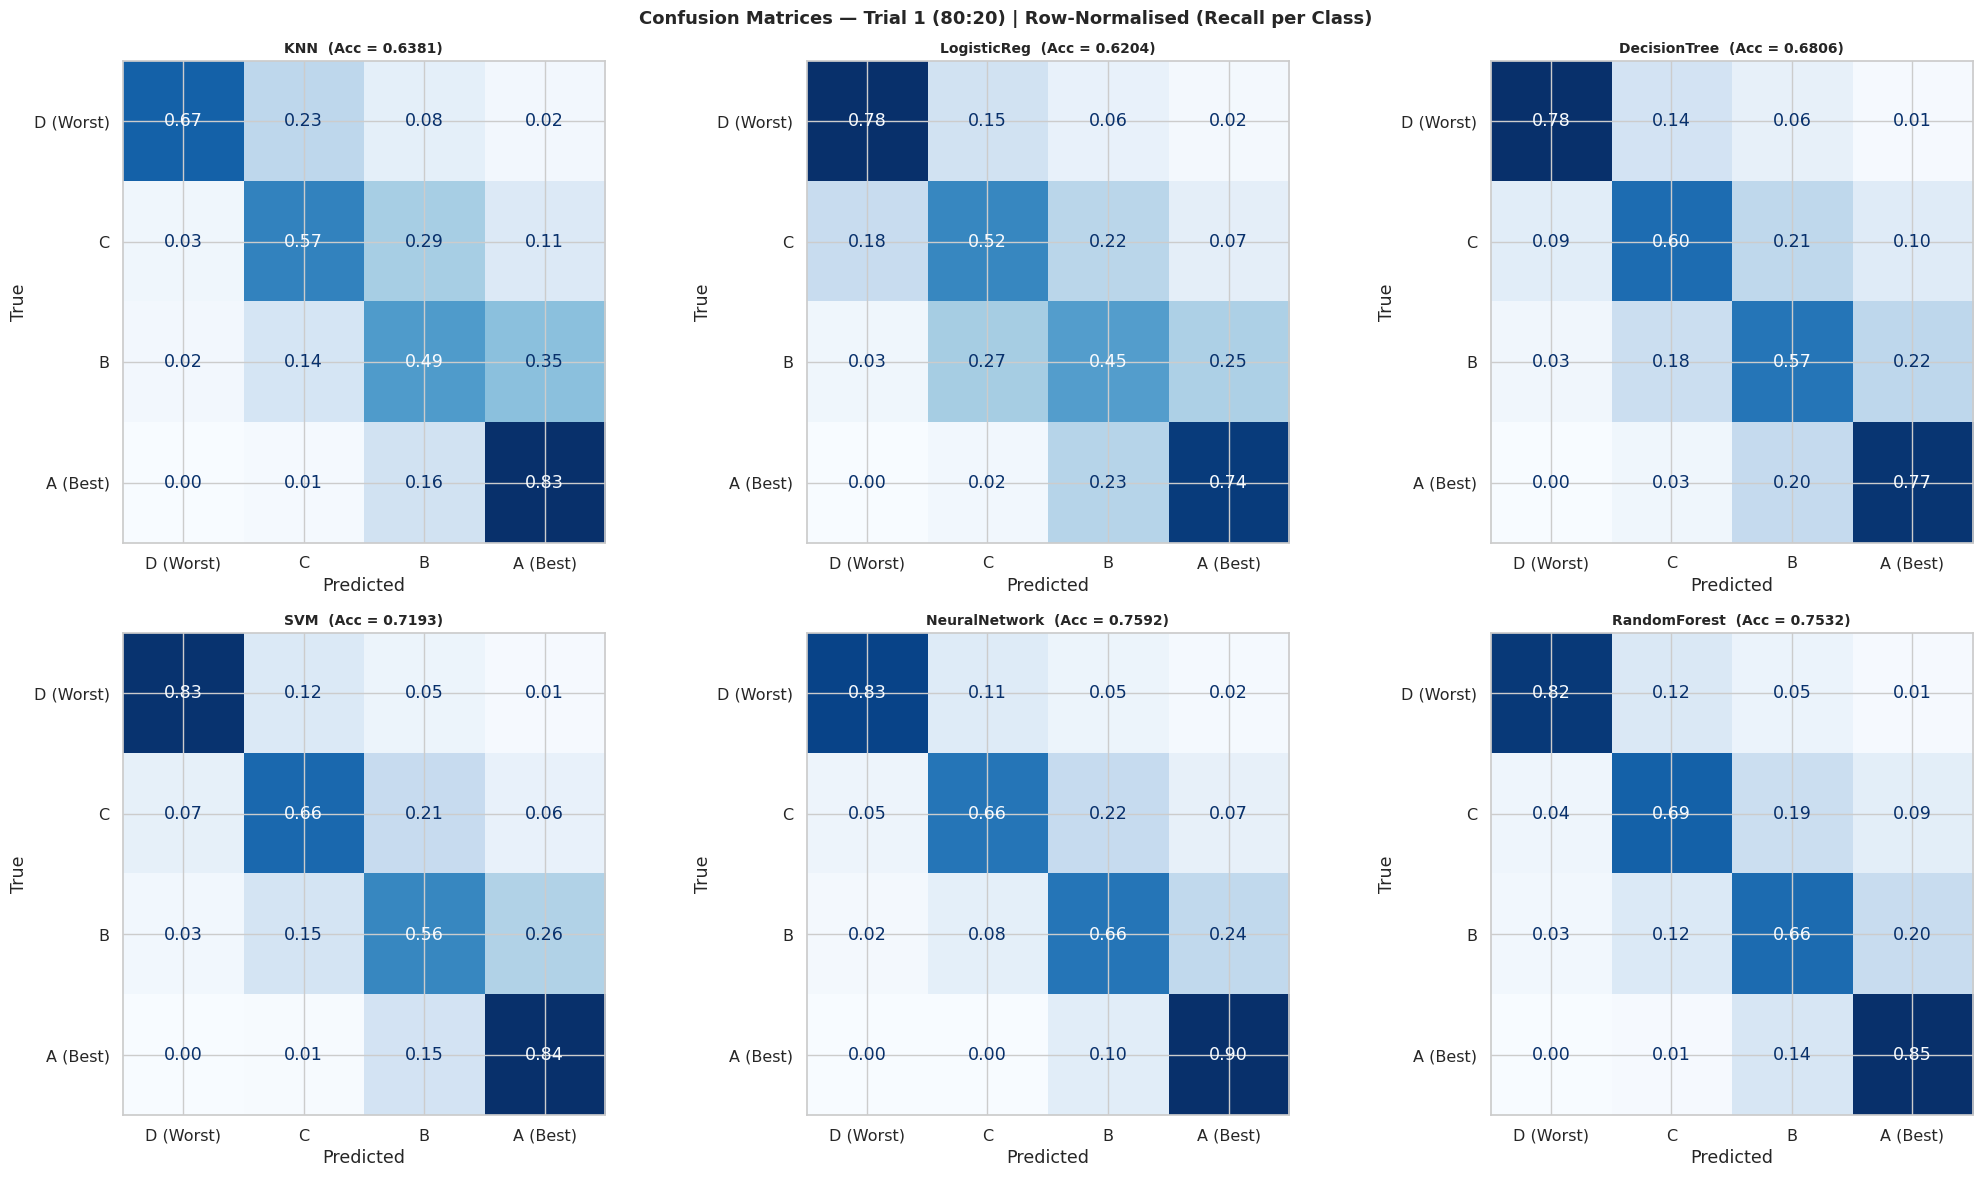

  Saved: confusion_matrices_t1.png


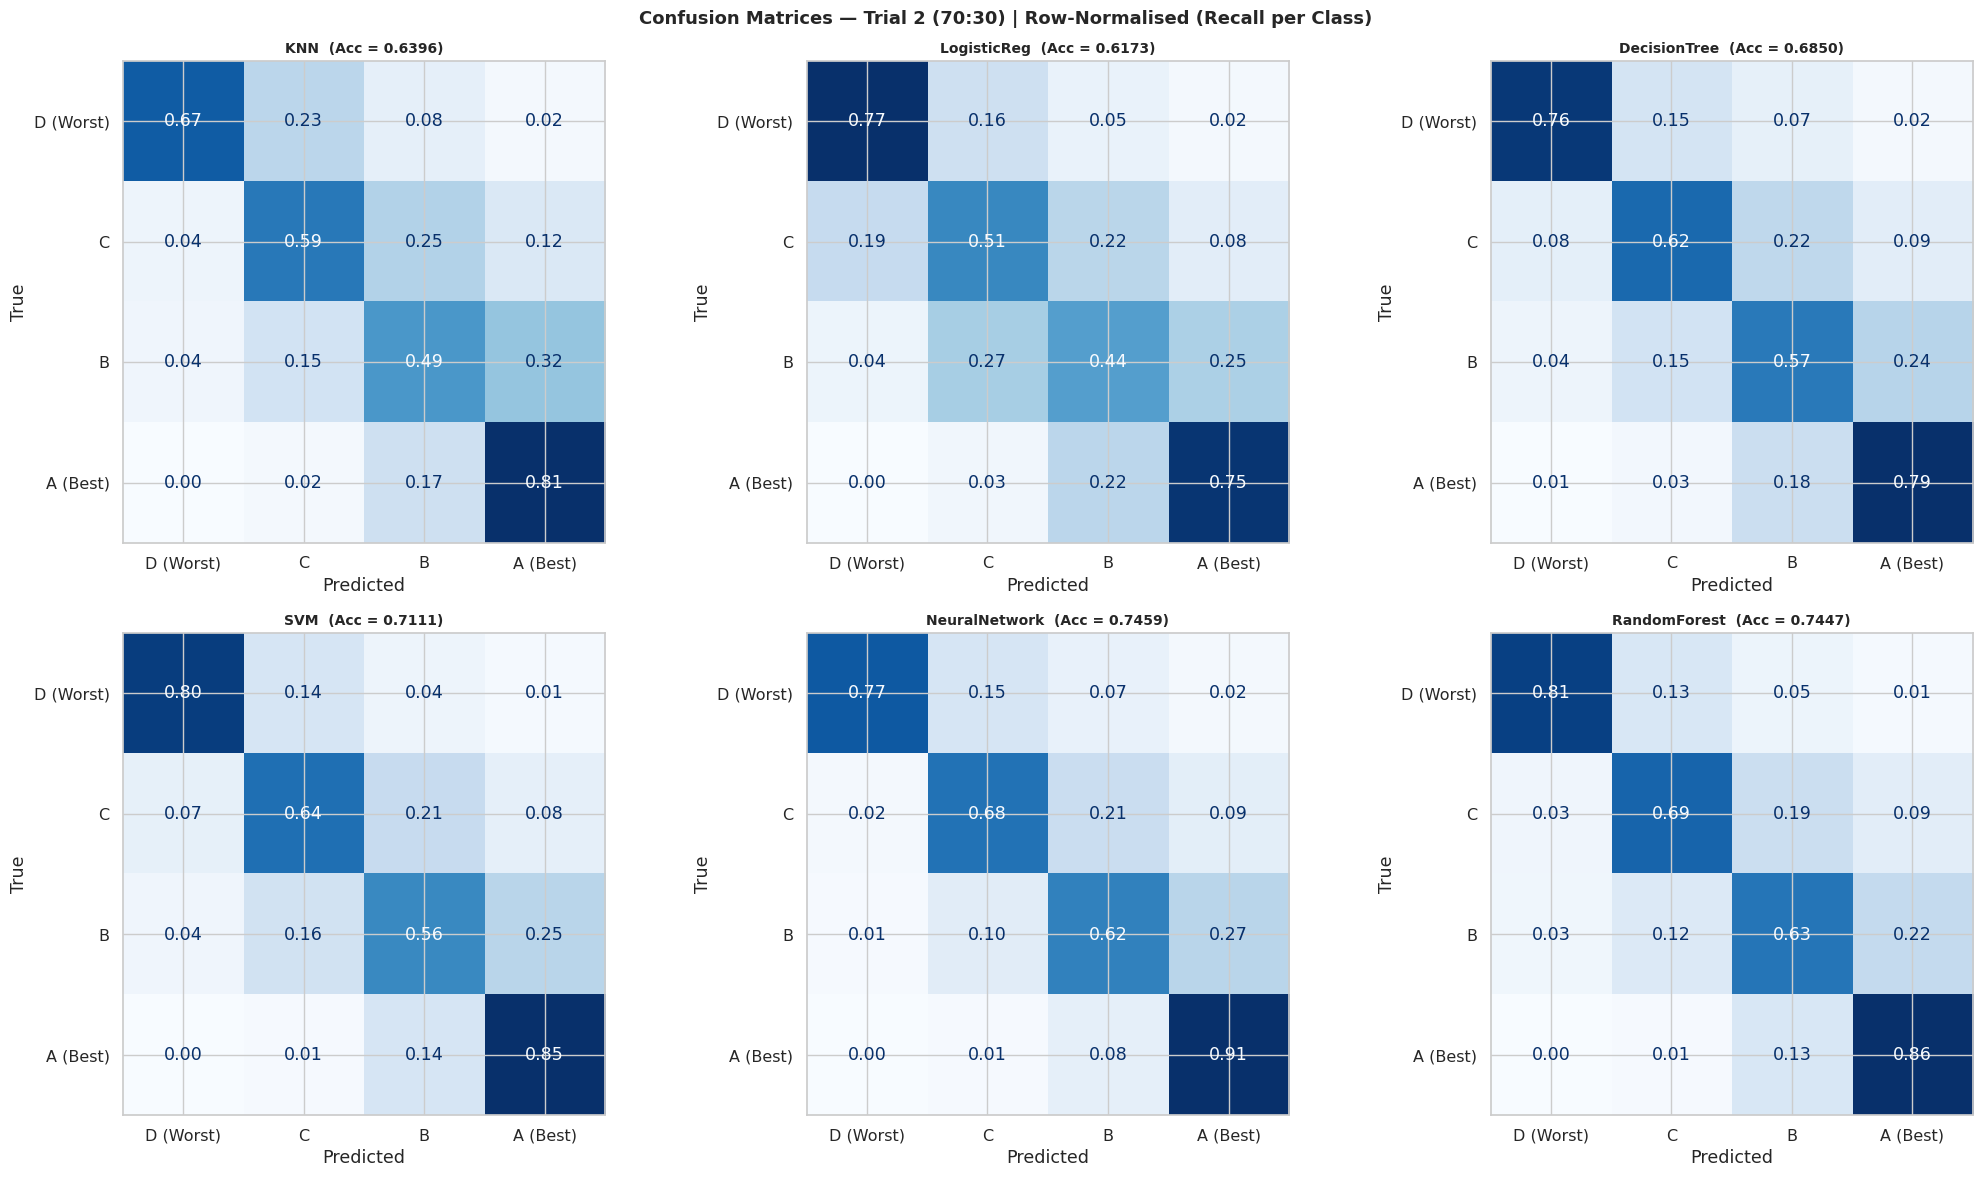

  Saved: confusion_matrices_t2.png


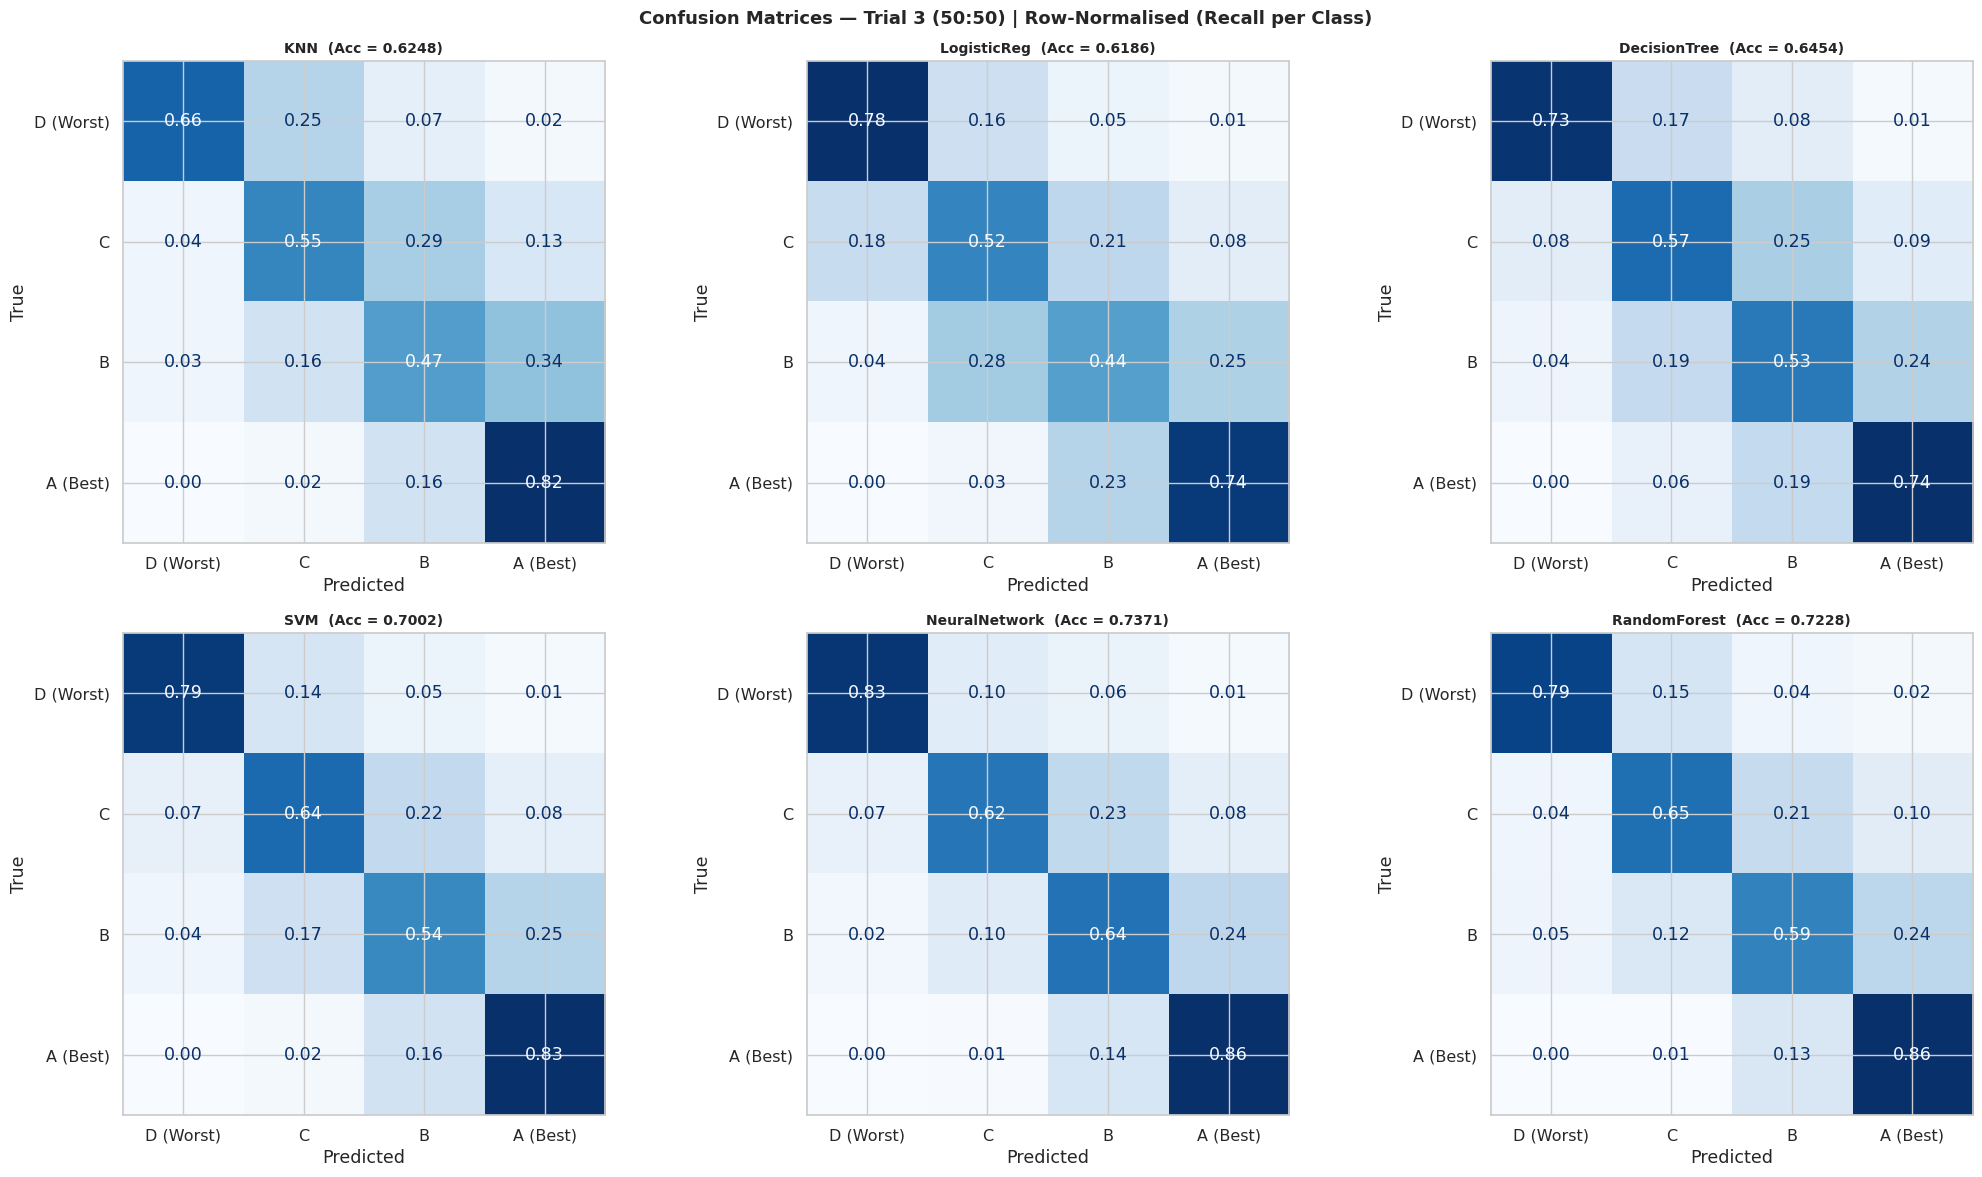

  Saved: confusion_matrices_t3.png


In [9]:
for t in TRIALS:
    tag = t["tag"]
    loaded_models = [n for n in MODEL_NAMES if (tag, n) in conf_matrices]
    n_models = len(loaded_models)

    ncols = 3
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows))
    axes = np.array(axes).flatten()

    for i, name in enumerate(loaded_models):
        ax = axes[i]
        cm = conf_matrices[(tag, name)]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        disp = ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")

        acc = results_df.loc[
            (results_df["Trial"] == t["label"]) &
            (results_df["Model"] == name), "Test Accuracy"
        ].values[0]

        ax.set_title(f"{name}  (Acc = {acc:.4f})",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    # Hide any unused subplot axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Confusion Matrices — {t['label']} | Row-Normalised (Recall per Class)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"confusion_matrices_{t['tag']}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: confusion_matrices_{t['tag']}.png")

## 📉 Section 6 — CV Accuracy vs Test Accuracy (Overfitting Check)

Loads `cv_results_t*.csv` saved by `04_Modelling.ipynb`.  
A gap > 3 pp is flagged as a possible sign of overfitting.

  Loaded: /content/cv_results_t1.csv
  Loaded: /content/cv_results_t2.csv
  Loaded: /content/cv_results_t3.csv

  Trial 1 (80:20)
  Model                  CV Acc   Test Acc        Gap
  ────────────────────────────────────────────────────
  NeuralNetwork          0.7344     0.7592    -0.0248
  RandomForest           0.7360     0.7532    -0.0172
  SVM                    0.7069     0.7193    -0.0125
  DecisionTree           0.6711     0.6806    -0.0095
  KNN                    0.6332     0.6381    -0.0049
  LogisticReg            0.6166     0.6204    -0.0038

  Trial 2 (70:30)
  Model                  CV Acc   Test Acc        Gap
  ────────────────────────────────────────────────────
  NeuralNetwork          0.7312     0.7459    -0.0147
  RandomForest           0.7309     0.7447    -0.0138
  SVM                    0.6987     0.7111    -0.0123
  DecisionTree           0.6599     0.6850    -0.0250
  KNN                    0.6238     0.6396    -0.0158
  LogisticReg            0.6192     0.6

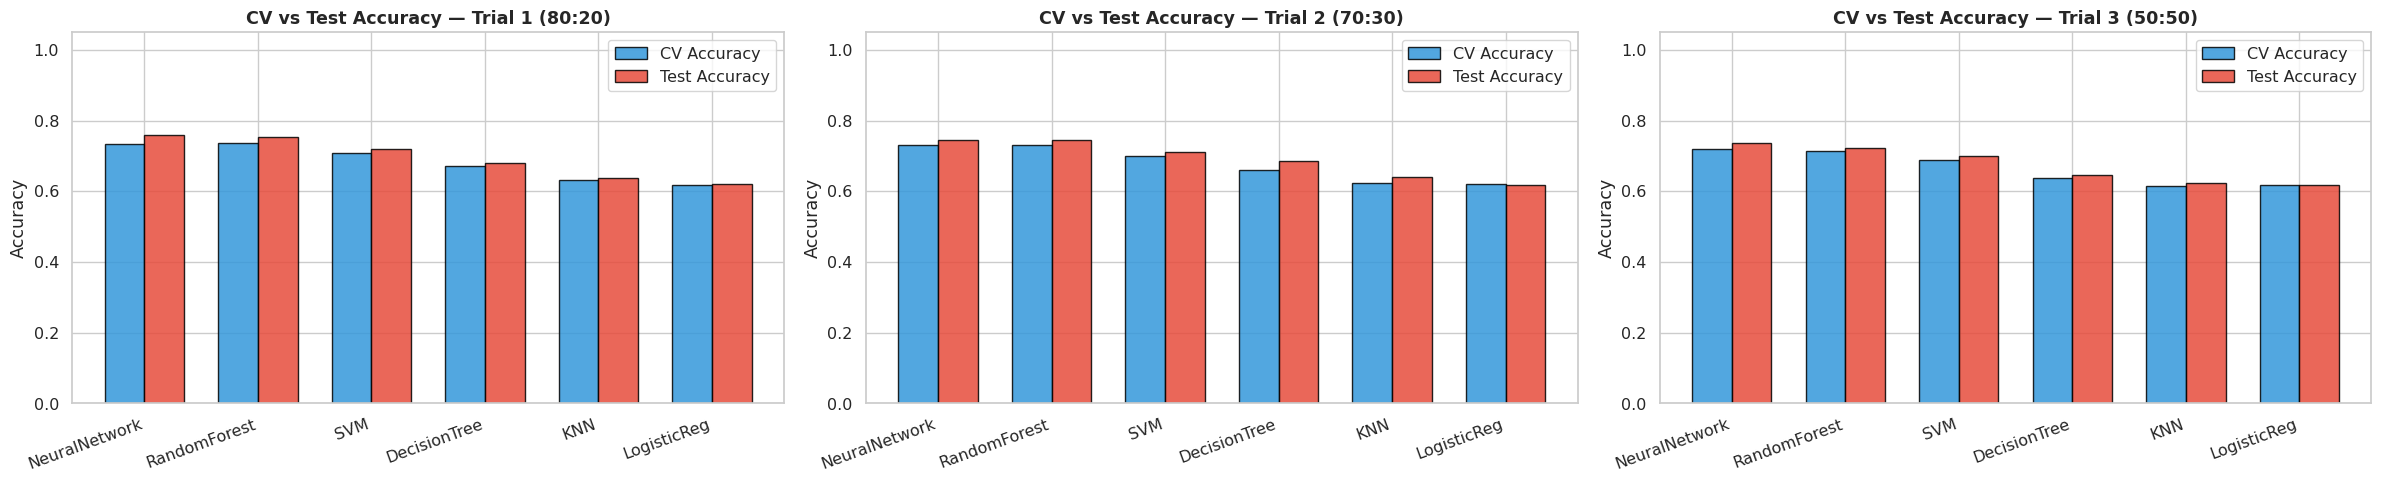


  Saved: cv_vs_test_accuracy.png


In [10]:
# ── Try to load cv_results files ─────────────────────────────────────────
cv_data = {}
for t in TRIALS:
    path = os.path.join(DATA_DIR, f"cv_results_{t['tag']}.csv")
    if os.path.exists(path):
        cv_data[t["tag"]] = pd.read_csv(path)
        print(f"  Loaded: {path}")
    else:
        print(f"  ⚠  NOT FOUND: {path}  (skipping overfitting check for {t['label']})")

if not cv_data:
    print("\n  No cv_results files found — Section 6 skipped.")
else:
    fig, axes = plt.subplots(1, len(cv_data), figsize=(8 * len(cv_data), 5))
    if len(cv_data) == 1:
        axes = [axes]

    for ax, (tag, cv_df) in zip(axes, cv_data.items()):
        # Normalise column names (modelling notebook uses 'model' / 'cv_accuracy')
        cv_df.columns = [c.strip().lower() for c in cv_df.columns]
        col_map = {"model": "Model", "cv_accuracy": "CV Accuracy",
                   "cv_acc": "CV Accuracy"}
        cv_df = cv_df.rename(columns={k: v for k, v in col_map.items() if k in cv_df.columns})

        label = next(t["label"] for t in TRIALS if t["tag"] == tag)
        test_sub = results_df[results_df["Trial"] == label][["Model", "Test Accuracy"]]

        compare = cv_df[["Model", "CV Accuracy"]].merge(test_sub, on="Model")
        compare["Gap"] = compare["CV Accuracy"] - compare["Test Accuracy"]
        compare = compare.sort_values("Test Accuracy", ascending=False)

        print(f"\n  {label}")
        print(f"  {'Model':<18} {'CV Acc':>10} {'Test Acc':>10} {'Gap':>10}")
        print("  " + "─"*52)
        for _, row in compare.iterrows():
            flag = " ⚠ possible overfit" if row["Gap"] > 0.03 else ""
            print(f"  {row['Model']:<18} {row['CV Accuracy']:>10.4f} "
                  f"{row['Test Accuracy']:>10.4f} {row['Gap']:>10.4f}{flag}")

        x = np.arange(len(compare))
        w = 0.35
        ax.bar(x - w/2, compare["CV Accuracy"],  w, label="CV Accuracy",
               color="#3498db", edgecolor="black", alpha=0.85)
        ax.bar(x + w/2, compare["Test Accuracy"], w, label="Test Accuracy",
               color="#e74c3c", edgecolor="black", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(compare["Model"], rotation=20, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Accuracy")
        ax.set_title(f"CV vs Test Accuracy — {label}", fontweight="bold")
        ax.legend()

    plt.tight_layout()
    plt.savefig("cv_vs_test_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  Saved: cv_vs_test_accuracy.png")

## 🌟 Section 7 — Cross-Trial Comparison (All 3 Splits)

Answers:
1. Which models are most data-hungry? (big accuracy drop from T1 → T3)
2. Which models generalise well even with 50 % training data?
3. Overall best model + split combination.

Test Accuracy across all trials:

Split             80:20     70:30     50:50 Best Split  Best Acc
Model                                                           
DecisionTree   0.680587  0.684976  0.645394      70:30  0.684976
KNN            0.638074  0.639579  0.624774      70:30  0.639579
LogisticReg    0.620391  0.617256  0.618603      80:20  0.620391
NeuralNetwork  0.759217  0.745924  0.737056      80:20  0.759217
RandomForest   0.753198  0.744670  0.722757      80:20  0.753198
SVM            0.719338  0.711061  0.700181      80:20  0.719338


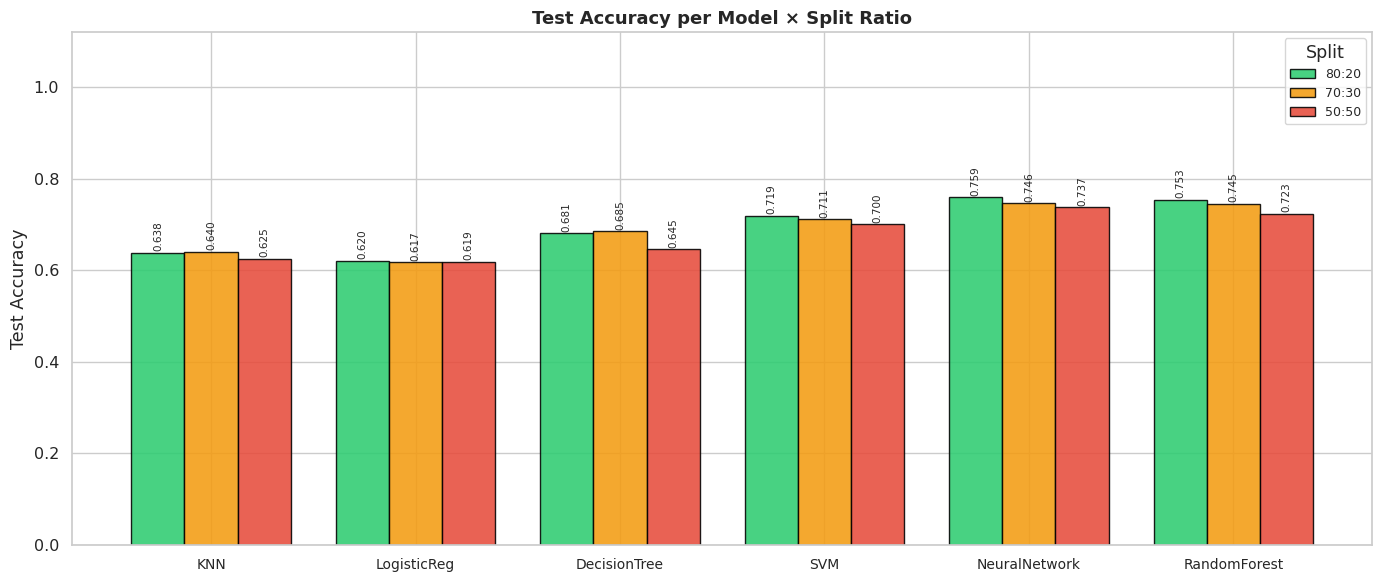

  Saved: cross_trial_accuracy.png


In [11]:
# ── Pivot: model × split → test accuracy ────────────────────────────────
pivot = results_df.pivot_table(
    index="Model", columns="Split",
    values="Test Accuracy", aggfunc="first"
)
splits_present = [t["split"] for t in TRIALS if t["split"] in pivot.columns]
pivot = pivot[splits_present]
pivot["Best Split"] = pivot.idxmax(axis=1)
pivot["Best Acc"]   = pivot[splits_present].max(axis=1)

print("Test Accuracy across all trials:\n")
print(pivot.to_string())

# ── Grouped bar chart ────────────────────────────────────────────────────
model_order  = MODEL_NAMES
split_labels = splits_present
x = np.arange(len(model_order))
w = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
for i, (split, color) in enumerate(zip(split_labels, PALETTE_TRIAL)):
    vals = [pivot.loc[m, split] if m in pivot.index else 0 for m in model_order]
    bars = ax.bar(x + i*w, vals, w, label=split,
                  color=color, edgecolor="black", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7.5, rotation=90)

ax.set_xticks(x + w)
ax.set_xticklabels(model_order, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy per Model × Split Ratio", fontweight="bold", fontsize=13)
ax.legend(title="Split", fontsize=9)

plt.tight_layout()
plt.savefig("cross_trial_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: cross_trial_accuracy.png")

### Accuracy Drop Chart: T1 (80:20) → T3 (50:50)

Model                 80:20    50:50     Drop
──────────────────────────────────────────────
DecisionTree         0.6806   0.6454   0.0352  ⚠ large drop
RandomForest         0.7532   0.7228   0.0304  ⚠ large drop
NeuralNetwork        0.7592   0.7371   0.0222  ⚠ large drop
SVM                  0.7193   0.7002   0.0192
KNN                  0.6381   0.6248   0.0133
LogisticReg          0.6204   0.6186   0.0018


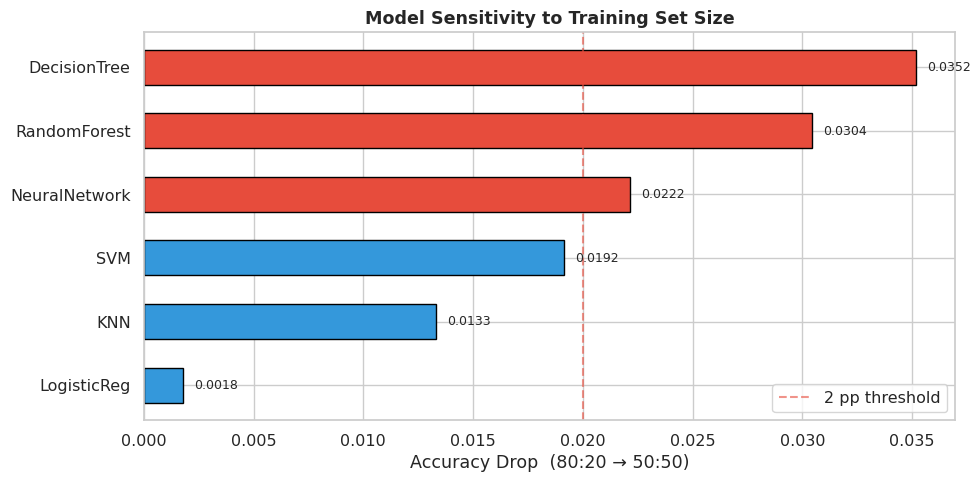

  Saved: accuracy_drop.png


In [12]:
if "80:20" in pivot.columns and "50:50" in pivot.columns:
    drops = []
    for m in model_order:
        if m in pivot.index:
            drops.append({
                "Model": m,
                "80:20": pivot.loc[m, "80:20"],
                "50:50": pivot.loc[m, "50:50"],
                "Drop" : pivot.loc[m, "80:20"] - pivot.loc[m, "50:50"],
            })

    drop_df = pd.DataFrame(drops).sort_values("Drop", ascending=False)

    print(f"{'Model':<18} {'80:20':>8} {'50:50':>8} {'Drop':>8}")
    print("─" * 46)
    for _, row in drop_df.iterrows():
        flag = "  ⚠ large drop" if row["Drop"] > 0.02 else ""
        print(f"{row['Model']:<18} {row['80:20']:>8.4f} {row['50:50']:>8.4f} "
              f"{row['Drop']:>8.4f}{flag}")

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#e74c3c" if d > 0.02 else "#3498db" for d in drop_df["Drop"]]
    bars = ax.barh(drop_df["Model"][::-1], drop_df["Drop"][::-1],
                   color=colors[::-1], edgecolor="black", height=0.55)
    for bar, val in zip(bars, drop_df["Drop"][::-1]):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Accuracy Drop  (80:20 → 50:50)")
    ax.set_title("Model Sensitivity to Training Set Size", fontweight="bold")
    ax.axvline(0.02, color="#e74c3c", linestyle="--", alpha=0.6, label="2 pp threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("accuracy_drop.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: accuracy_drop.png")
else:
    print("  Both 80:20 and 50:50 splits needed for drop chart — skipping.")

## 🌟 Section 8 — Feature Importance Analysis

Uses **Trial 1 (80:20)** models — largest training set gives most stable estimates.

- **Random Forest**: built-in Gini impurity importance  
- **Logistic Regression**: mean absolute coefficient across classes

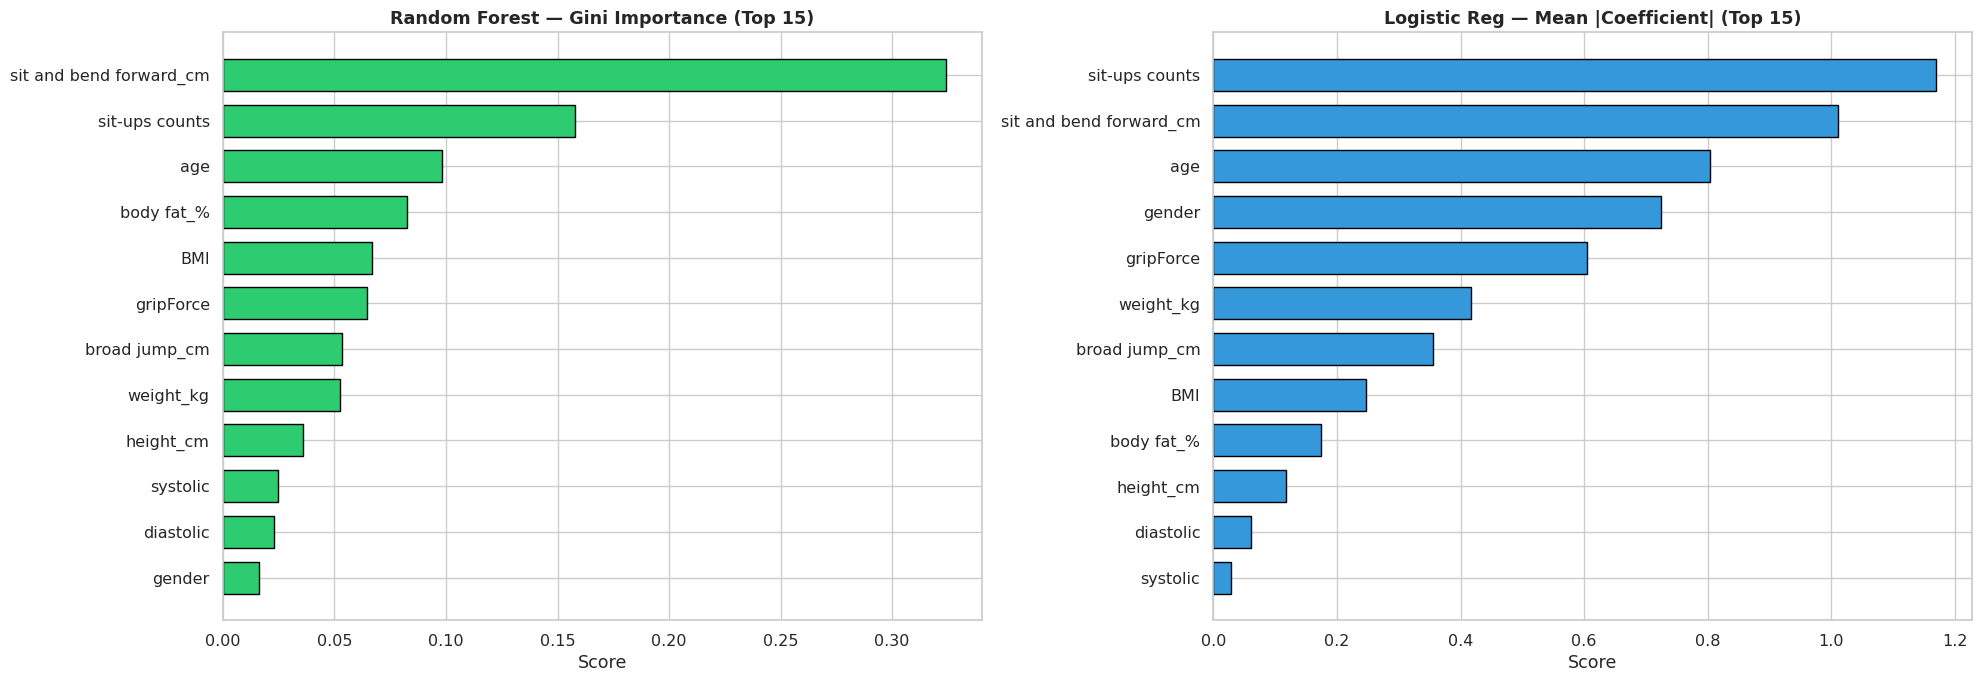

  Saved: feature_importance.png


In [13]:
rf_model = models["t1"].get("RandomForest")
lr_model = models["t1"].get("LogisticReg")

plots = []

if rf_model is not None:
    try:
        rf_imp = pd.DataFrame({
            "Feature"   : FEATURE_NAMES,
            "Importance": rf_model.named_steps["clf"].feature_importances_
        }).sort_values("Importance", ascending=False).head(15)
        plots.append((rf_imp, "Importance",
                      "Random Forest — Gini Importance (Top 15)", "#2ecc71"))
    except Exception as e:
        print(f"RF importance error: {e}")

if lr_model is not None:
    try:
        coef = np.abs(lr_model.named_steps["clf"].coef_).mean(axis=0)
        lr_imp = pd.DataFrame({
            "Feature": FEATURE_NAMES,
            "Coeff"  : coef
        }).sort_values("Coeff", ascending=False).head(15)
        plots.append((lr_imp, "Coeff",
                      "Logistic Reg — Mean |Coefficient| (Top 15)", "#3498db"))
    except Exception as e:
        print(f"LR coefficient error: {e}")

if plots:
    fig, axes = plt.subplots(1, len(plots), figsize=(10 * len(plots), 7))
    if len(plots) == 1:
        axes = [axes]
    for ax, (df_imp, col, title, color) in zip(axes, plots):
        ax.barh(df_imp["Feature"][::-1], df_imp[col][::-1],
                color=color, edgecolor="black", height=0.7)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: feature_importance.png")
else:
    print("  No models available for feature importance analysis.")

## 🕸️ Section 9 — Radar Charts (Multi-Metric, Per Trial)

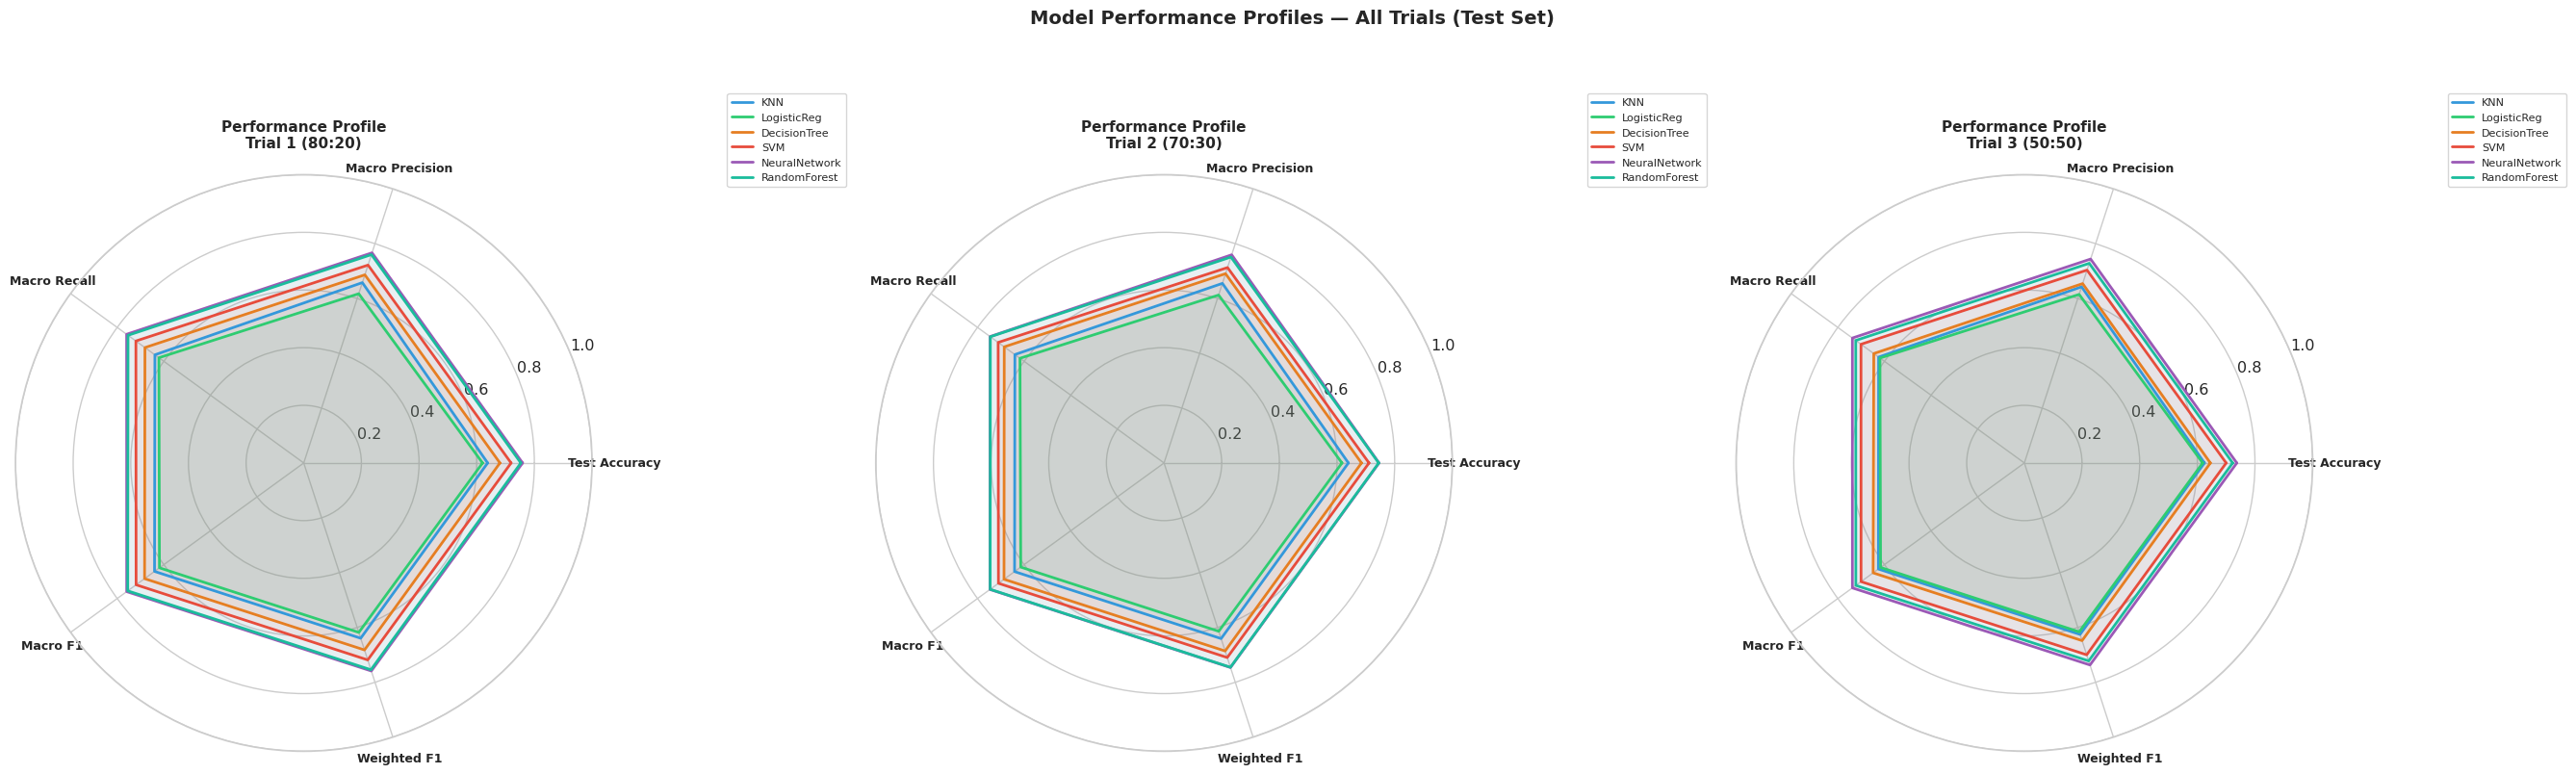

  Saved: radar_charts.png


In [14]:
radar_metrics = ["Test Accuracy", "Macro Precision",
                 "Macro Recall", "Macro F1", "Weighted F1"]
n_m    = len(radar_metrics)
angles = [n/n_m * 2*np.pi for n in range(n_m)] + [0]

fig, axes = plt.subplots(1, len(TRIALS), figsize=(9*len(TRIALS), 8),
                          subplot_kw={"polar": True})
if len(TRIALS) == 1:
    axes = [axes]

for ax, t in zip(axes, TRIALS):
    sub = results_df[results_df["Trial"] == t["label"]].reset_index(drop=True)

    for _, row in sub.iterrows():
        color = MODEL_COLOR[row["Model"]]
        vals  = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
        ax.plot(angles, vals, lw=2, label=row["Model"], color=color)
        ax.fill(angles, vals, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, size=9, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title(f"Performance Profile\n{t['label']}",
                 fontsize=11, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=8)

fig.suptitle("Model Performance Profiles — All Trials (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("radar_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: radar_charts.png")

## 🏆 Section 10 — Final Summary Report

In [15]:
print("\n" + "="*65)
print("   BODY PERFORMANCE CLASSIFIER — FINAL RESULTS")
print("="*65)
print(f"  Dataset  : Body Performance (post-cleaning)")
print(f"  Task     : 4-class ordinal classification (A / B / C / D)")
print(f"  Features : {len(FEATURE_NAMES)}  →  {FEATURE_NAMES}")
print(f"  Trials   : {len(TRIALS)}  (80:20, 70:30, 50:50 stratified hold-outs)")

# ── Per-trial leaderboard ─────────────────────────────────────────────────
for t in TRIALS:
    sub = (results_df[results_df["Trial"] == t["label"]]
           .sort_values("Test Accuracy", ascending=False)
           .reset_index(drop=True))
    best = sub.iloc[0]

    print(f"\n  ── {t['label']} ─────────────────────────────────────")
    print(f"  {'Rank':<5} {'Model':<16} {'Acc':>8} {'MacF1':>8} {'WtF1':>8}")
    print("  " + "─"*50)
    for rank, (_, row) in enumerate(sub.iterrows(), 1):
        flag = "  ← 🏆 BEST" if rank == 1 else ""
        print(f"  {rank:<5} {row['Model']:<16} "
              f"{row['Test Accuracy']:>8.4f} "
              f"{row['Macro F1']:>8.4f} "
              f"{row['Weighted F1']:>8.4f}{flag}")

# ── Overall leaderboard ───────────────────────────────────────────────────
print("\n  ── OVERALL Leaderboard (all trials combined) ──────────")
overall = (results_df
           .sort_values("Test Accuracy", ascending=False)
           .reset_index(drop=True))
print(f"  {'Rank':<5} {'Trial':<22} {'Model':<16} {'Acc':>8} {'MacF1':>8}")
print("  " + "─"*60)
for rank, (_, row) in enumerate(overall.iterrows(), 1):
    flag = "  ← 🏆 OVERALL BEST" if rank == 1 else ""
    print(f"  {rank:<5} {row['Trial']:<22} {row['Model']:<16} "
          f"{row['Test Accuracy']:>8.4f} {row['Macro F1']:>8.4f}{flag}")

overall_best = overall.iloc[0]
print(f"""
  ┌─────────────────────────────────────────────────┐
  │  Overall Best Model : {overall_best['Model']:<27}│
  │  Best Split         : {overall_best['Split']:<27}│
  │  Test Accuracy      : {overall_best['Test Accuracy']:.4f}                      │
  │  Macro F1           : {overall_best['Macro F1']:.4f}                      │
  │  Weighted F1        : {overall_best['Weighted F1']:.4f}                      │
  └─────────────────────────────────────────────────┘
""")
print("✅ Evaluation complete.")


   BODY PERFORMANCE CLASSIFIER — FINAL RESULTS
  Dataset  : Body Performance (post-cleaning)
  Task     : 4-class ordinal classification (A / B / C / D)
  Features : 12  →  ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'BMI']
  Trials   : 3  (80:20, 70:30, 50:50 stratified hold-outs)

  ── Trial 1 (80:20) ─────────────────────────────────────
  Rank  Model                 Acc    MacF1     WtF1
  ──────────────────────────────────────────────────
  1     NeuralNetwork      0.7592   0.7592   0.7588  ← 🏆 BEST
  2     RandomForest       0.7532   0.7547   0.7543
  3     SVM                0.7193   0.7189   0.7184
  4     DecisionTree       0.6806   0.6826   0.6820
  5     KNN                0.6381   0.6399   0.6393
  6     LogisticReg        0.6204   0.6188   0.6181

  ── Trial 2 (70:30) ─────────────────────────────────────
  Rank  Model                 Acc    MacF1     WtF1
  ─